# Week 6 - Feature Engineering

Extend the Week 5 model comparison with property-level ratios, property age, and a California school-district spatial layer. The evaluation remains fixed to a 30-month training window (November 2023 through April 2026) and the May 2026 test month so old and new feature sets are directly comparable.

## Setup

This notebook uses the Week 3 cleaned CSV and the original CRMLS files. It also uses GeoPandas to spatially join valid property coordinates to the California Department of Education's [California School District Areas 2024-25](https://data.ca.gov/dataset/california-school-district-areas-2024-25/resource/7dfaf005-58eb-45db-93b1-7aff091b2172) boundaries.

Install the geospatial dependencies once if needed:

```bash
python3 -m pip install scikit-learn geopandas pyogrio
```

In [1]:
from pathlib import Path
from time import perf_counter
from urllib.request import urlretrieve

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

DATA_DIR = Path("data")
CLEANED_PATH = DATA_DIR / "week3_cleaned.csv"
RAW_PATHS = sorted(DATA_DIR.glob("CRMLSSold*.csv"))
DISTRICT_PATH = DATA_DIR / "ca_school_district_areas_2024_25.geojson"
DISTRICT_URL = (
    "https://gis.data.ca.gov/api/download/v1/items/"
    "b0e3b936426a47ce9d9a2e77e2bb86cc/geojson?layers=0"
)

if not CLEANED_PATH.exists():
    raise FileNotFoundError("Missing data/week3_cleaned.csv. Run 02_preprocessing.ipynb first.")
if not RAW_PATHS:
    raise FileNotFoundError("Missing raw CRMLS CSV files in data/.")

pd.options.display.float_format = "{:,.4f}".format
RANDOM_STATE = 50
TRAINING_MONTHS = 30
WEEK4_BASELINE_R2 = 0.2999484390

## Load modeling and raw property fields

Week 3 stored the model-ready numeric features. `RecordId` is recreated from the unchanged raw-file order so the notebook can recover city, ZIP, coordinates, and the raw fields needed for feature engineering.

In [2]:
cleaned = pd.read_csv(CLEANED_PATH)
week3_metadata_cols = {"RecordId", "CloseDate", "CloseMonth", "ClosePrice", "split"}
week3_feature_cols = [column for column in cleaned.columns if column not in week3_metadata_cols]

RAW_FEATURES = [
    "City", "PostalCode", "Latitude", "Longitude", "YearBuilt",
    "BedroomsTotal", "BathroomsTotalInteger", "LivingArea", "LotSizeSquareFeet",
]


def load_raw_feature_fields(raw_paths):
    frames = []
    start_id = 0

    for path in raw_paths:
        header = pd.read_csv(path, nrows=0).columns
        usecols = [column for column in RAW_FEATURES if column in header]
        frame = pd.read_csv(path, usecols=usecols, low_memory=False)

        for column in RAW_FEATURES:
            if column not in frame:
                frame[column] = pd.NA

        frame["RecordId"] = np.arange(start_id, start_id + len(frame), dtype=np.int64)
        start_id += len(frame)
        frames.append(frame[["RecordId"] + RAW_FEATURES])

    raw = pd.concat(frames, ignore_index=True)
    raw["City_clean"] = (
        raw["City"].astype("string").str.strip().str.upper().replace("", pd.NA)
    )
    raw["PostalCode_clean"] = (
        raw["PostalCode"]
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str[:5]
        .replace("", pd.NA)
    )
    raw["ZIP3"] = raw["PostalCode_clean"].str[:3]
    return raw.drop(columns=["City", "PostalCode"])


raw_fields = load_raw_feature_fields(RAW_PATHS)
df = cleaned.merge(raw_fields, on="RecordId", how="left", validate="one_to_one")

display(df[["RecordId", "CloseMonth", "ClosePrice", "split", "City_clean", "PostalCode_clean"]].head())
display(pd.Series({"rows": len(df), "columns": len(df.columns), "raw_files": len(RAW_PATHS)}).to_frame("value"))

,RecordId,CloseMonth,ClosePrice,split,City_clean,PostalCode_clean
0,149621,2023-05,"695,960.0000",train,CARSON,90745
1,150236,2023-05,"1,700,000.0000",train,COSTA MESA,92626
2,150421,2023-05,"1,575,000.0000",train,SOUTH PASADENA,91030
3,150422,2023-05,"2,675,000.0000",train,SUNNYVALE,94087
4,150446,2023-05,"1,900,000.0000",train,DANA POINT,92629


,value
rows,393502
columns,55
raw_files,30


## Keep the Week 5 target rules and time split

The target is restricted to at least $50,000 and at most the available training data's 99.5th percentile. The final training window is the 30 months immediately before May 2026.

In [3]:
LOWER_PRICE_BOUND = 50_000
train_target = df.loc[df["split"].eq("train"), "ClosePrice"]
UPPER_PRICE_BOUND = train_target.quantile(0.995)

target_keep_mask = df["ClosePrice"].between(LOWER_PRICE_BOUND, UPPER_PRICE_BOUND)
removed_summary = pd.DataFrame(
    {
        "rows_before": df.groupby("split").size(),
        "rows_removed": df.loc[~target_keep_mask].groupby("split").size(),
    }
).fillna(0).astype(int)
removed_summary["rows_after"] = removed_summary["rows_before"] - removed_summary["rows_removed"]
removed_summary["removed_percent"] = removed_summary["rows_removed"] / removed_summary["rows_before"] * 100

model_df = df.loc[target_keep_mask].copy()
model_df["CloseMonthPeriod"] = pd.PeriodIndex(model_df["CloseMonth"], freq="M")
test_month = model_df.loc[model_df["split"].eq("test"), "CloseMonthPeriod"].max()
train_start_month = test_month - TRAINING_MONTHS

time_keep_mask = (
    (model_df["split"].eq("test") & model_df["CloseMonthPeriod"].eq(test_month))
    | (
        model_df["split"].eq("train")
        & model_df["CloseMonthPeriod"].between(train_start_month, test_month - 1)
    )
)
model_df = model_df.loc[time_keep_mask].drop(columns="CloseMonthPeriod").copy()

split_summary = pd.Series(
    {
        "training_months_used": TRAINING_MONTHS,
        "train_start_month": str(train_start_month),
        "train_end_month": str(test_month - 1),
        "test_month": str(test_month),
        "train_rows": int(model_df["split"].eq("train").sum()),
        "test_rows": int(model_df["split"].eq("test").sum()),
        "lower_price_bound": LOWER_PRICE_BOUND,
        "upper_price_bound": UPPER_PRICE_BOUND,
    }
)
display(removed_summary)
display(split_summary.to_frame("value"))

,rows_before,rows_removed,rows_after,removed_percent
split,,,,
test,12024,72,11952,0.5988
train,381478,2005,379473,0.5256


,value
training_months_used,30
train_start_month,2023-11
train_end_month,2026-04
test_month,2026-05
train_rows,325846
test_rows,11952
lower_price_bound,50000
upper_price_bound,"8,150,000.0000"


## Spatially join school-district boundaries

Invalid or out-of-state coordinates are not joined. California's source combines three district systems, so each property retains separate unified, elementary, and high-school district fields. This avoids losing information where elementary and high-school areas overlap.

In [4]:
if not DISTRICT_PATH.exists():
    print("Downloading official California school-district boundaries...")
    urlretrieve(DISTRICT_URL, DISTRICT_PATH)

district_columns = [
    "CDCode", "DistrictName", "DistrictType", "EnrollTotal",
    "SEDpct", "DistrctAreaSqMi", "geometry",
]
districts = gpd.read_file(DISTRICT_PATH)[district_columns].to_crs("EPSG:4326")


def add_school_district_fields(frame, boundaries):
    latitude = pd.to_numeric(frame["Latitude"], errors="coerce")
    longitude = pd.to_numeric(frame["Longitude"], errors="coerce")
    valid_coordinates = latitude.between(32.0, 42.5) & longitude.between(-125.0, -114.0)

    points = gpd.GeoDataFrame(
        frame.loc[valid_coordinates, ["RecordId"]].copy(),
        geometry=gpd.points_from_xy(
            longitude.loc[valid_coordinates], latitude.loc[valid_coordinates]
        ),
        crs="EPSG:4326",
    )
    enriched = frame.copy()

    for district_type in ["Unified", "Elementary", "High"]:
        prefix = district_type.lower()
        layer = boundaries.loc[
            boundaries["DistrictType"].eq(district_type),
            ["CDCode", "DistrictName", "EnrollTotal", "SEDpct", "DistrctAreaSqMi", "geometry"],
        ]
        joined = gpd.sjoin(points, layer, how="left", predicate="within")
        joined = (
            joined.sort_values(["RecordId", "CDCode"], na_position="last")
            .drop_duplicates("RecordId")
            .drop(columns=["geometry", "index_right"])
            .rename(
                columns={
                    "CDCode": f"{prefix}_district_code",
                    "DistrictName": f"{prefix}_district_name",
                    "EnrollTotal": f"{prefix}_district_enrollment",
                    "SEDpct": f"{prefix}_district_sed_pct",
                    "DistrctAreaSqMi": f"{prefix}_district_area_sqmi",
                }
            )
        )
        enriched = enriched.merge(joined, on="RecordId", how="left", validate="one_to_one")

    enriched["valid_coordinate"] = enriched["RecordId"].isin(points["RecordId"]).astype("int8")
    district_code_cols = [
        "unified_district_code", "elementary_district_code", "high_district_code"
    ]
    enriched["school_district_match_count"] = enriched[district_code_cols].notna().sum(axis=1)
    enriched["school_district_any_match"] = enriched["school_district_match_count"].gt(0).astype("int8")
    return enriched


join_start = perf_counter()
model_df = add_school_district_fields(model_df, districts)
join_seconds = perf_counter() - join_start

district_coverage = pd.DataFrame(
    {
        "matched_rows": {
            "valid coordinates": model_df["valid_coordinate"].sum(),
            "any district": model_df["school_district_any_match"].sum(),
            "unified": model_df["unified_district_code"].notna().sum(),
            "elementary": model_df["elementary_district_code"].notna().sum(),
            "high": model_df["high_district_code"].notna().sum(),
        }
    }
)
district_coverage["percent_of_model_rows"] = district_coverage["matched_rows"] / len(model_df) * 100
display(district_coverage)
print(f"Spatial join completed in {join_seconds:.1f} seconds.")

,matched_rows,percent_of_model_rows
valid coordinates,337599,99.9411
any district,337560,99.9295
unified,253002,74.8974
elementary,86020,25.4649
high,84349,24.9702


Spatial join completed in 2.0 seconds.


## Engineer property and categorical geography features

Property age is measured at the close date. Ratios use raw values, with invalid denominators treated as missing. Every engineered numeric feature is clipped and imputed from the training partition only. The existing city and ZIP identifiers keep their Week 5 smoothed log-price encoding: leave-one-out values for training rows and training-only aggregates for test rows.

In [5]:
train = model_df[model_df["split"].eq("train")].copy()
test = model_df[model_df["split"].eq("test")].copy()


def add_smoothed_log_target_encoding(train, test, column, smoothing=50):
    encoded_name = f"{column}_log_price_te"
    count_name = f"{column}_count_log"

    train_key = train[column].fillna("__MISSING__").astype("string")
    test_key = test[column].fillna("__MISSING__").astype("string")
    train_log_target = np.log1p(train["ClosePrice"])
    global_mean = train_log_target.mean()

    stats = (
        pd.DataFrame({column: train_key, "log_target": train_log_target})
        .groupby(column)["log_target"]
        .agg(["count", "sum"])
    )
    train_count = train_key.map(stats["count"]).astype(float)
    train_sum = train_key.map(stats["sum"]).astype(float)
    loo_count = train_count - 1
    loo_sum = train_sum - train_log_target.to_numpy()

    train[encoded_name] = np.where(
        loo_count > 0,
        (loo_sum + smoothing * global_mean) / (loo_count + smoothing),
        global_mean,
    )
    smoothed_test_map = (stats["sum"] + smoothing * global_mean) / (stats["count"] + smoothing)
    train[count_name] = np.log1p(train_count)
    test[encoded_name] = test_key.map(smoothed_test_map).fillna(global_mean)
    test[count_name] = np.log1p(test_key.map(stats["count"]).fillna(0).astype(float))
    return train, test, [encoded_name, count_name]


location_feature_cols = []
for location_column in ["City_clean", "PostalCode_clean", "ZIP3"]:
    train, test, added = add_smoothed_log_target_encoding(
        train, test, location_column, smoothing=50
    )
    location_feature_cols.extend(added)


def add_train_clipped_feature(train, test, output_name, train_values, test_values):
    train_values = pd.Series(train_values, index=train.index).replace([np.inf, -np.inf], np.nan)
    test_values = pd.Series(test_values, index=test.index).replace([np.inf, -np.inf], np.nan)
    lower, upper = train_values.quantile([0.005, 0.995])
    median = train_values.clip(lower, upper).median()

    missing_name = f"{output_name}_missing"
    train[missing_name] = train_values.isna().astype("int8")
    test[missing_name] = test_values.isna().astype("int8")
    train[output_name] = train_values.clip(lower, upper).fillna(median)
    test[output_name] = test_values.clip(lower, upper).fillna(median)
    return train, test, [output_name, missing_name]


train_close_year = pd.to_datetime(train["CloseDate"]).dt.year
test_close_year = pd.to_datetime(test["CloseDate"]).dt.year

train_age = train_close_year - pd.to_numeric(train["YearBuilt"], errors="coerce")
test_age = test_close_year - pd.to_numeric(test["YearBuilt"], errors="coerce")
train_age = train_age.where(train_age.between(0, 250))
test_age = test_age.where(test_age.between(0, 250))

train_baths = pd.to_numeric(train["BathroomsTotalInteger"], errors="coerce")
test_baths = pd.to_numeric(test["BathroomsTotalInteger"], errors="coerce")
train_beds = pd.to_numeric(train["BedroomsTotal"], errors="coerce")
test_beds = pd.to_numeric(test["BedroomsTotal"], errors="coerce")
train_living = pd.to_numeric(train["LivingArea"], errors="coerce")
test_living = pd.to_numeric(test["LivingArea"], errors="coerce")
train_lot = pd.to_numeric(train["LotSizeSquareFeet"], errors="coerce")
test_lot = pd.to_numeric(test["LotSizeSquareFeet"], errors="coerce")

property_specs = {
    "PropertyAgeYears": (train_age, test_age),
    "BedBathRatio": (train_beds.div(train_baths.where(train_baths.gt(0))), test_beds.div(test_baths.where(test_baths.gt(0)))),
    "LivingAreaPerBedroom": (train_living.div(train_beds.where(train_beds.gt(0))), test_living.div(test_beds.where(test_beds.gt(0)))),
    "LivingAreaPerBathroom": (train_living.div(train_baths.where(train_baths.gt(0))), test_living.div(test_baths.where(test_baths.gt(0)))),
    "LotUtilizationRatio": (train_living.div(train_lot.where(train_lot.gt(0))), test_living.div(test_lot.where(test_lot.gt(0)))),
}

property_feature_cols = []
for output_name, (train_values, test_values) in property_specs.items():
    train, test, added = add_train_clipped_feature(
        train, test, output_name, train_values, test_values
    )
    property_feature_cols.extend(added)

display(train[property_feature_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
PropertyAgeYears,"325,846.0000",49.0730,27.3211,0.0000,27.0000,49.0000,69.0000,119.0000
PropertyAgeYears_missing,"325,846.0000",0.0007,0.0265,0.0000,0.0000,0.0000,0.0000,1.0000
BedBathRatio,"325,846.0000",1.4638,0.4692,0.6667,1.0000,1.5000,1.5000,3.0000
BedBathRatio_missing,"325,846.0000",0.0006,0.0236,0.0000,0.0000,0.0000,0.0000,1.0000
LivingAreaPerBedroom,"325,846.0000",573.4680,182.0722,283.5000,444.6667,538.0000,660.0000,"1,323.5765"
LivingAreaPerBedroom_missing,"325,846.0000",0.0009,0.0301,0.0000,0.0000,0.0000,0.0000,1.0000
LivingAreaPerBathroom,"325,846.0000",788.1569,192.2095,398.2500,649.0000,766.6667,900.7875,"1,465.0000"
LivingAreaPerBathroom_missing,"325,846.0000",0.0009,0.0308,0.0000,0.0000,0.0000,0.0000,1.0000
LotUtilizationRatio,"325,846.0000",0.2688,0.1731,0.0035,0.1679,0.2354,0.3296,1.1781
LotUtilizationRatio_missing,"325,846.0000",0.0180,0.1330,0.0000,0.0000,0.0000,0.0000,1.0000


## Encode the school-district layer

Public boundary attributes add district enrollment, socioeconomic-disadvantage percentage, and district area separately for unified, elementary, and high-school systems. Missing flags distinguish unified-only areas from elementary/high overlaps and unmatched coordinates. District codes and names remain available for audit, but are not target encoded: an ablation check found that their historical price averages were too brittle for the May 2026 tree-model holdout.

In [6]:
district_numeric_feature_cols = [
    "valid_coordinate", "school_district_match_count", "school_district_any_match"
]

for prefix in ["unified", "elementary", "high"]:
    numeric_specs = {
        f"{prefix}_district_enrollment_log": (
            np.log1p(pd.to_numeric(train[f"{prefix}_district_enrollment"], errors="coerce")),
            np.log1p(pd.to_numeric(test[f"{prefix}_district_enrollment"], errors="coerce")),
        ),
        f"{prefix}_district_sed_share": (
            pd.to_numeric(train[f"{prefix}_district_sed_pct"], errors="coerce") / 100,
            pd.to_numeric(test[f"{prefix}_district_sed_pct"], errors="coerce") / 100,
        ),
        f"{prefix}_district_area_log": (
            np.log1p(pd.to_numeric(train[f"{prefix}_district_area_sqmi"], errors="coerce")),
            np.log1p(pd.to_numeric(test[f"{prefix}_district_area_sqmi"], errors="coerce")),
        ),
    }
    for output_name, (train_values, test_values) in numeric_specs.items():
        train, test, added = add_train_clipped_feature(
            train, test, output_name, train_values, test_values
        )
        district_numeric_feature_cols.extend(added)

district_feature_cols = district_numeric_feature_cols
display(pd.Series({
    "property_features_added": len(property_feature_cols),
    "district_features_added": len(district_feature_cols),
    "district_numeric_features": len(district_numeric_feature_cols),
}).to_frame("count"))

,count
property_features_added,10
district_features_added,21
district_numeric_features,21


## Define old and new feature sets

`Old (Week 5)` recreates the prior model matrix. `New (Week 6)` adds only the engineered property and school-district features, keeping every row, split rule, target rule, and model setting fixed.

In [7]:
old_feature_cols = week3_feature_cols + location_feature_cols
new_feature_cols = old_feature_cols + property_feature_cols + district_feature_cols

# Final guardrail: use training-only medians for any values still missing after
# the feature-specific transforms (and zero only if a column is entirely missing).
all_model_feature_cols = list(dict.fromkeys(new_feature_cols))
remaining_missing_before_fill = pd.DataFrame({
    "train_missing": train[all_model_feature_cols].isna().sum(),
    "test_missing": test[all_model_feature_cols].isna().sum(),
})
remaining_missing_before_fill = remaining_missing_before_fill.loc[
    remaining_missing_before_fill.sum(axis=1).gt(0)
]
final_train_medians = train[all_model_feature_cols].median(numeric_only=True)
train[all_model_feature_cols] = (
    train[all_model_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(final_train_medians)
    .fillna(0)
)
test[all_model_feature_cols] = (
    test[all_model_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(final_train_medians)
    .fillna(0)
)

if not remaining_missing_before_fill.empty:
    display(remaining_missing_before_fill)

feature_sets = {
    "Old (Week 5)": old_feature_cols,
    "New (Week 6 + school districts)": new_feature_cols,
}
y_train = train["ClosePrice"]
y_test = test["ClosePrice"]

matrix_summary = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "train_rows": len(train),
            "test_rows": len(test),
            "feature_count": len(columns),
            "missing_train_values": int(train[columns].isna().sum().sum()),
            "missing_test_values": int(test[columns].isna().sum().sum()),
        }
        for feature_set_name, columns in feature_sets.items()
    ]
)
display(matrix_summary)

assert matrix_summary[["missing_train_values", "missing_test_values"]].to_numpy().sum() == 0

,feature_set,train_rows,test_rows,feature_count,missing_train_values,missing_test_values
0,Old (Week 5),325846,11952,46,0,0
1,New (Week 6 + school districts),325846,11952,77,0,0


## Re-train and compare models

Each model is trained twice with identical hyperparameters. The paired evaluation isolates the effect of Week 6 feature engineering on the same May 2026 holdout observations.

In [8]:
def make_models():
    return {
        "Linear Regression": LinearRegression(),
        "Decision Tree Regressor": DecisionTreeRegressor(
            max_depth=22,
            min_samples_leaf=25,
            random_state=RANDOM_STATE,
        ),
        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=60,
            max_depth=22,
            min_samples_leaf=10,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    }


def median_absolute_percentage_error(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true))


results_rows = []
fitted_models = {}
predictions = {}

for feature_set_name, columns in feature_sets.items():
    X_train = train[columns]
    X_test = test[columns]

    for model_name, model in make_models().items():
        start = perf_counter()
        model.fit(X_train, y_train)
        fit_seconds = perf_counter() - start
        y_pred = model.predict(X_test)

        fitted_models[(feature_set_name, model_name)] = model
        predictions[(feature_set_name, model_name)] = y_pred
        results_rows.append(
            {
                "feature_set": feature_set_name,
                "model": model_name,
                "feature_count": len(columns),
                "test_r2": r2_score(y_test, y_pred),
                "mae": mean_absolute_error(y_test, y_pred),
                "rmse": root_mean_squared_error(y_test, y_pred),
                "mdape": median_absolute_percentage_error(y_test, y_pred),
                "negative_predictions": int((y_pred < 0).sum()),
                "fit_seconds": fit_seconds,
            }
        )

results = pd.DataFrame(results_rows).sort_values(
    ["model", "feature_set"]
).reset_index(drop=True)

display(results.style.format({
    "test_r2": "{:.4f}",
    "mae": "${:,.0f}",
    "rmse": "${:,.0f}",
    "mdape": "{:.2%}",
    "fit_seconds": "{:.1f}",
}))

,feature_set,model,feature_count,test_r2,mae,rmse,mdape,negative_predictions,fit_seconds
0,New (Week 6 + school districts),Decision Tree Regressor,77,0.7439,"$260,714","$493,310",14.31%,0,9.4
1,Old (Week 5),Decision Tree Regressor,46,0.7353,"$267,366","$501,570",14.79%,0,5.8
2,New (Week 6 + school districts),Linear Regression,77,0.7454,"$301,820","$491,896",19.97%,326,0.7
3,Old (Week 5),Linear Regression,46,0.7355,"$310,575","$501,385",20.61%,421,0.4
4,New (Week 6 + school districts),Random Forest Regressor,77,0.8511,"$189,388","$376,182",9.72%,0,7.0
5,Old (Week 5),Random Forest Regressor,46,0.8377,"$199,699","$392,768",10.58%,0,5.4


## Old vs. new feature-set table

Positive R² change means the Week 6 property and school-district features improved the model on the untouched test month.

In [9]:
r2_comparison = (
    results.pivot(index="model", columns="feature_set", values="test_r2")
    .rename(columns={
        "Old (Week 5)": "old_feature_r2",
        "New (Week 6 + school districts)": "new_feature_r2",
    })
    .reset_index()
)
r2_comparison["r2_change"] = (
    r2_comparison["new_feature_r2"] - r2_comparison["old_feature_r2"]
)
r2_comparison["relative_error_reduction"] = (
    1 - (1 - r2_comparison["new_feature_r2"]) / (1 - r2_comparison["old_feature_r2"])
)
r2_comparison = r2_comparison.sort_values("new_feature_r2", ascending=False).reset_index(drop=True)

display(r2_comparison.style.format({
    "old_feature_r2": "{:.4f}",
    "new_feature_r2": "{:.4f}",
    "r2_change": "{:+.4f}",
    "relative_error_reduction": "{:+.2%}",
}))

feature_set,model,new_feature_r2,old_feature_r2,r2_change,relative_error_reduction
0,Random Forest Regressor,0.8511,0.8377,+0.0134,+8.27%
1,Linear Regression,0.7454,0.7355,+0.0099,+3.75%
2,Decision Tree Regressor,0.7439,0.7353,+0.0086,+3.27%


## Diagnostics and feature importance

,feature,importance
42,PostalCode_clean_log_price_te,0.2041
40,City_clean_log_price_te,0.1363
1,LivingArea_scaled,0.1207
44,ZIP3_log_price_te,0.0929
5,Bathrooms_scaled,0.0796
50,LivingAreaPerBedroom,0.0529
48,BedBathRatio,0.0284
61,unified_district_sed_share,0.0234
67,elementary_district_sed_share,0.0221
45,ZIP3_count_log,0.0195


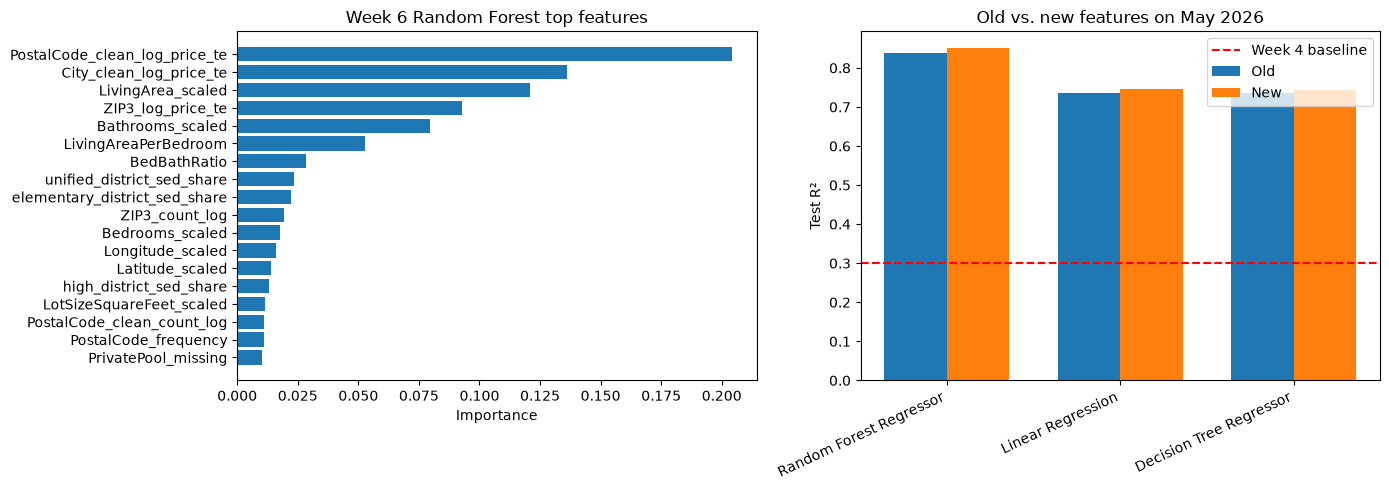

In [10]:
new_set_name = "New (Week 6 + school districts)"
forest_model = fitted_models[(new_set_name, "Random Forest Regressor")]
forest_importance = (
    pd.DataFrame({"feature": new_feature_cols, "importance": forest_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(18)
)
display(forest_importance)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(forest_importance["feature"][::-1], forest_importance["importance"][::-1])
axes[0].set_title("Week 6 Random Forest top features")
axes[0].set_xlabel("Importance")

x = np.arange(len(r2_comparison))
width = 0.36
axes[1].bar(x - width / 2, r2_comparison["old_feature_r2"], width, label="Old")
axes[1].bar(x + width / 2, r2_comparison["new_feature_r2"], width, label="New")
axes[1].axhline(WEEK4_BASELINE_R2, color="red", linestyle="--", label="Week 4 baseline")
axes[1].set_xticks(x, r2_comparison["model"], rotation=25, ha="right")
axes[1].set_ylabel("Test R²")
axes[1].set_title("Old vs. new features on May 2026")
axes[1].legend()

plt.tight_layout()

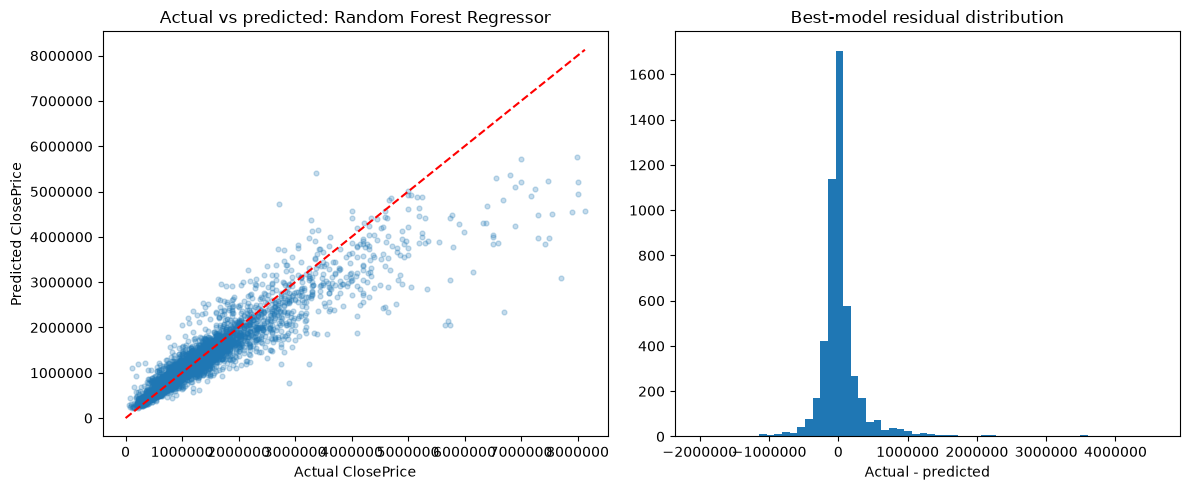

In [11]:
best_key = results.sort_values("test_r2", ascending=False).iloc[0]
best_pair = (best_key["feature_set"], best_key["model"])
best_predictions = predictions[best_pair]

plot_data = pd.DataFrame(
    {
        "actual": y_test.to_numpy(),
        "predicted": best_predictions,
        "residual": y_test.to_numpy() - best_predictions,
    }
).sample(n=min(5_000, len(y_test)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(plot_data["actual"], plot_data["predicted"], alpha=0.25, s=12)
price_max = max(plot_data["actual"].max(), plot_data["predicted"].max())
axes[0].plot([0, price_max], [0, price_max], color="red", linestyle="--")
axes[0].set_title(f"Actual vs predicted: {best_pair[1]}")
axes[0].set_xlabel("Actual ClosePrice")
axes[0].set_ylabel("Predicted ClosePrice")
axes[0].ticklabel_format(style="plain", axis="both")

axes[1].hist(plot_data["residual"], bins=60)
axes[1].set_title("Best-model residual distribution")
axes[1].set_xlabel("Actual - predicted")
axes[1].ticklabel_format(style="plain", axis="x")
plt.tight_layout()

## Model behavior notes

- **Linear Regression:** remains fast and interpretable. Ratios, age, and district encodings give it nonlinear and regional signals that raw scaled fields cannot express directly, but it can still produce implausible negative predictions.
- **Decision Tree:** captures interactions without a linearity assumption and does not produce negative prices here. A single tree remains sensitive to its splits and is more likely to overfit local patterns.
- **Random Forest:** averages many trees, usually giving the strongest and most stable test performance. It costs more training time and feature importance is less directly interpretable than a linear coefficient.
- **School-district layer:** offers finer regional information than city or ZIP alone. The selected enrollment, disadvantage-share, and district-area features are public attributes and do not use sale prices. District identity target encodings were tested but excluded after they destabilized the tree holdout results.

## Week 6 outcome

The old-vs-new table measures the incremental value of property ratios, age, and the 2024-25 school-district layer on the same 30-month training window and May 2026 test month. Random Forest remains the primary candidate when it has the highest holdout R²; the paired R² change shows whether the engineered features add generalizable signal rather than only training complexity.